# Spatial join
Example: assign neighborhood to each restaurant


In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as cx

nyc = gpd.read_file("./data/nyc.geojson")
nyc_restaurant = pd.read_csv("./data/google_maps_restaurants(cleaned).csv")


In [4]:
# convert nyc_restaurant to geopandas dataframe, specify CRS the same as nyc.crs
nyc_restaurant_gdf = gpd.GeoDataFrame(
    nyc_restaurant, geometry=gpd.points_from_xy(nyc_restaurant.Lon, nyc_restaurant.Lat), crs=nyc.crs)

In [6]:
# inspect crs

nyc_restaurant_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

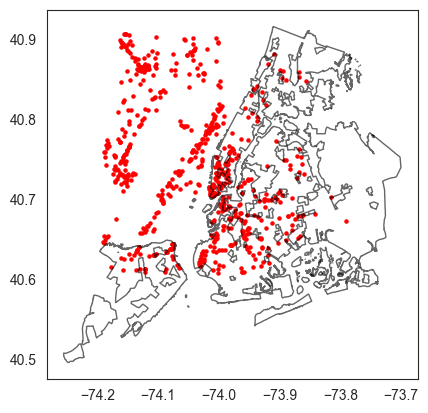

In [70]:
# Plot the restaurant locations
ax=nyc_restaurant_gdf.plot(color='red', markersize=5)
nyc.dissolve().plot(edgecolor='black', facecolor='none', ax=ax, alpha=0.6)


In [ ]:
# use sjoin to identify which neighborhood (Community District) each restaurant is in

joined_gdf = nyc_restaurant_gdf.sjoin(nyc, how='inner', predicate='intersects')

joined_gdf[['Name','Rating','Rating Count','Price Category',"Address",'BoroName','NTAName','CDTANAME']].head()

In [21]:
# Which community has the most expensive

restaurant_in_community = joined_gdf.groupby("CDTANAME", as_index=False).agg(
    Boro=("BoroName", "first"),
    NTAName=("NTAName", "first"),
    count=('Rating', 'count'),
    avg_rating=('Rating', 'mean'),
    avg_price_category=('Price Category', 'mean'),
)

restaurant_in_community.head()

,CDTANAME,Boro,NTAName,count,avg_rating,avg_price_category
0,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),Brooklyn,Greenpoint,10,4.2600,1.750000
1,BK02 Downtown Brooklyn-Fort Greene (CD 2 Appro...,Brooklyn,Brooklyn Heights,17,4.3000,1.941176
2,BK03 Bedford-Stuyvesant (CD 3 Approximation),Brooklyn,Bedford-Stuyvesant (East),2,4.3500,1.000000
3,BK04 Bushwick (CD 4 Equivalent),Brooklyn,Bushwick (West),8,4.2375,1.571429
4,BK05 East New York-Cypress Hills (CD 5 Approxi...,Brooklyn,Cypress Hills,10,3.8600,1.333333


In [22]:
restaurant_in_community_gdf = pd.merge(left=nyc, right=restaurant_in_community.drop(columns=["Boro",'NTAName']), on='CDTANAME', how='left')

Text(0.5, 0.9, 'Average restaurant price category in NYC communities')

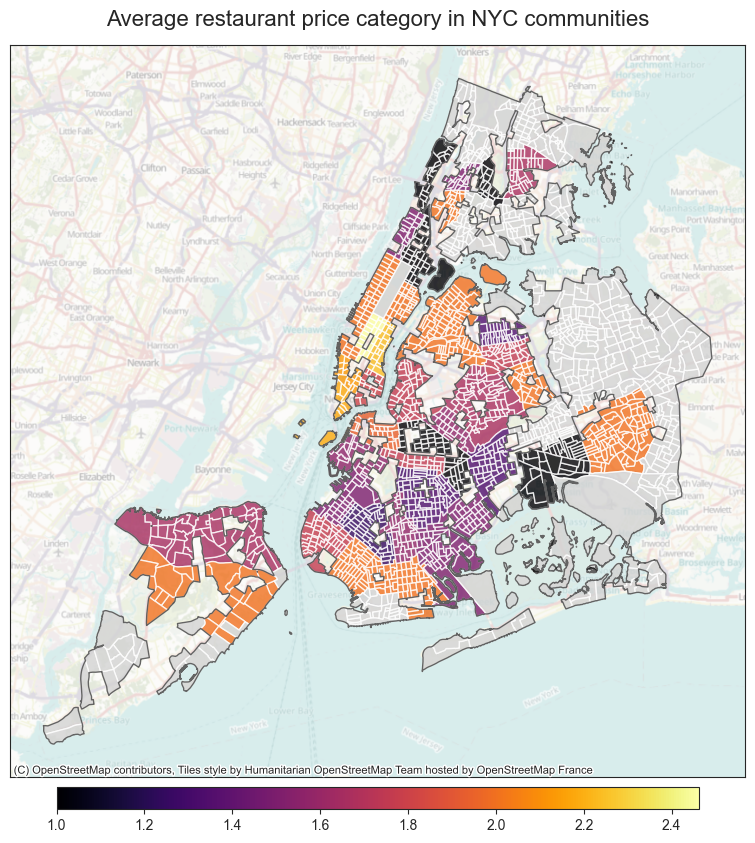

In [67]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

sns.set_style("white")
fig, ax = plt.subplots(1,1, figsize=(10,10), tight_layout=True)

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="3%", pad=0.1, aspect=0.05)

restaurant_in_community_gdf.plot(column='avg_price_category', cmap='inferno',
                                    missing_kwds={"color": "lightgrey"}, alpha=0.8, ax=ax, cax=cax, legend=True,
                                 legend_kwds={"orientation": "horizontal"})
nyc.dissolve().plot(edgecolor='black', facecolor='none', ax=ax, alpha=0.6)

cx.add_basemap(ax, crs=nyc.crs, alpha=0.35)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.suptitle('Average restaurant price category in NYC communities', y=0.9, fontsize=16)

# Buffer
Example: create service area for grocery stores

In [75]:
import geopandas as gpd
import geodatasets
import seaborn as sns
import matplotlib.pyplot as plt
import contextily as cx

chicago = gpd.read_file(geodatasets.get_path("geoda.chicago_commpop"))
groceries = gpd.read_file(geodatasets.get_path("geoda.groceries"))

chicago.head()


,community,NID,POP2010,POP2000,POPCH,POPPERCH,popplus,popneg,geometry
0,DOUGLAS,35,18238,26470,-8232,-31.099358,0,1,"MULTIPOLYGON (((-87.60914 41.84469, -87.60915 ..."
1,OAKLAND,36,5918,6110,-192,-3.142390,0,1,"MULTIPOLYGON (((-87.59215 41.81693, -87.59231 ..."
2,FULLER PARK,37,2876,3420,-544,-15.906433,0,1,"MULTIPOLYGON (((-87.6288 41.80189, -87.62879 4..."
3,GRAND BOULEVARD,38,21929,28006,-6077,-21.698922,0,1,"MULTIPOLYGON (((-87.60671 41.81681, -87.6067 4..."
4,KENWOOD,39,17841,18363,-522,-2.842673,0,1,"MULTIPOLYGON (((-87.59215 41.81693, -87.59215 ..."


In [74]:
groceries.head()

,OBJECTID,Ycoord,Xcoord,Status,Address,Chain,Category,geometry
0,16,41.973266,-87.657073,OPEN,"1051 W ARGYLE ST, CHICAGO, IL. 60640",VIET HOA PLAZA,None,MULTIPOINT ((1168268.672 1933554.35))
1,18,41.696367,-87.681315,OPEN,"10800 S WESTERN AVE, CHICAGO, IL. 60643-3226",COUNTY FAIR FOODS,None,MULTIPOINT ((1162302.618 1832900.224))
2,22,41.868634,-87.638638,OPEN,"1101 S CANAL ST, CHICAGO, IL. 60607-4932",WHOLE FOODS MARKET,None,MULTIPOINT ((1173317.042 1895425.426))
3,23,41.877590,-87.654953,OPEN,"1101 W JACKSON BLVD, CHICAGO, IL. 60607-2905",TARGET/SUPER,new,MULTIPOINT ((1168996.475 1898801.406))
4,27,41.737696,-87.625795,OPEN,"112 W 87TH ST, CHICAGO, IL. 60620-1318",FOOD 4 LESS,None,MULTIPOINT ((1176991.989 1847262.423))


In [80]:
print(chicago.crs)
print(groceries.crs)

EPSG:3857
EPSG:3857


In [79]:
# Project to Meter-Based CRS, since we need meters for buffer distance:
chicago = chicago.to_crs(epsg=3857)
groceries = groceries.to_crs(epsg=3857)

In [96]:
# 1000 meters = 1 km
groceries["buffer"] = groceries.geometry.buffer(1500)

# Convert to GeoDataFrame
buffers = groceries.set_geometry("buffer")

Text(0.5, 0.92, 'Chicago grocery stores and their service areas')

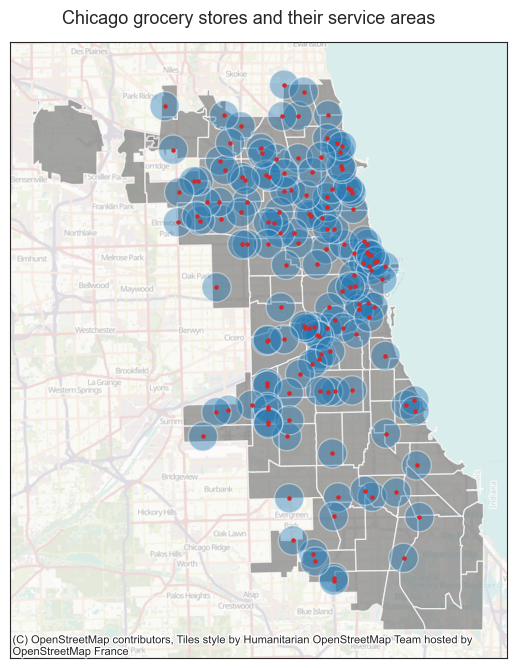

In [97]:

ax = chicago.plot(figsize=(8,8), color="gray", edgecolor="white", alpha=0.7)
buffers.plot(ax=ax, color="tab:blue", alpha=0.4)
groceries.plot(ax=ax, color="tab:red", markersize=5)

cx.add_basemap(ax, crs=chicago.crs, alpha=0.35)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.suptitle('Chicago grocery stores and their service areas', y=0.92, fontsize=13)

## Find underserved communities in Chicago

In [105]:
buffer_union = buffers.dissolve()
intersection = gpd.overlay(chicago, buffer_union, how="intersection")
chicago["total_area"] = chicago.geometry.area
intersection["covered_area"] = intersection.geometry.area
covered_area = (
    intersection.groupby("community")["covered_area"]
    .sum()
    .reset_index()
)

chicago_merged = chicago.merge(covered_area, on="community", how="left")

# Fill NaN (no coverage → 0)
chicago_merged["covered_area"] = chicago_merged["covered_area"].fillna(0)

chicago_merged["coverage_ratio"] = (
    chicago_merged["covered_area"] / chicago_merged["total_area"]
)

Text(0.5, 0.92, 'Chicago grocery coverage per community')

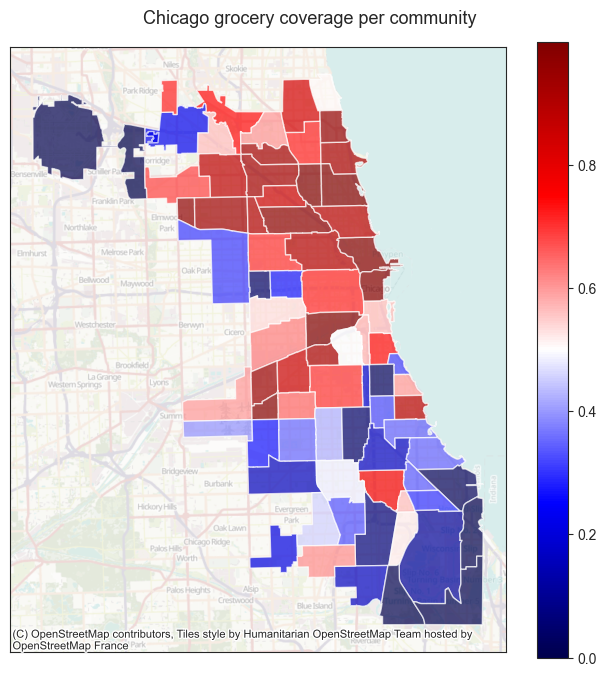

In [110]:
ax=chicago_merged.plot(
    column="coverage_ratio",
    cmap="seismic",
    legend=True,
    figsize=(8,8), alpha=0.7,
    edgecolor="white",
)

cx.add_basemap(ax, crs=chicago.crs, alpha=0.35)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.suptitle('Chicago grocery coverage per community', y=0.92, fontsize=13)

In [112]:
# find food desert in Chicago
chicago_merged["food_desert"] = chicago_merged["coverage_ratio"] < 0.2